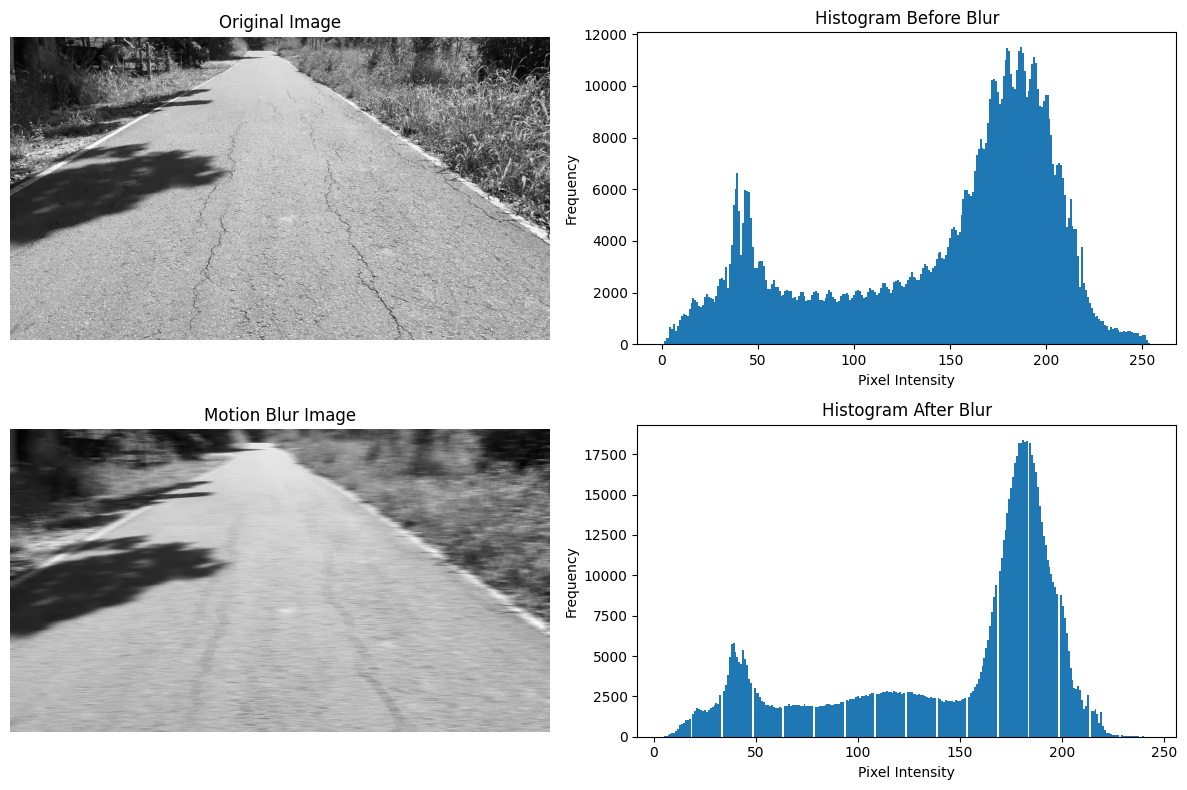

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
img = cv2.imread("frames/frame_100.jpg")

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Create motion blur kernel
kernel_size = 25
kernel = np.zeros((kernel_size, kernel_size))
kernel[kernel_size // 2, :] = np.ones(kernel_size)
kernel = kernel / kernel_size

# Apply motion blur
motion_blur = cv2.filter2D(gray, -1, kernel)

# Plot images and histograms
plt.figure(figsize=(12,8))

# Original image
plt.subplot(2,2,1)
plt.title("Original Image")
plt.imshow(gray, cmap='gray')
plt.axis('off')

# Histogram before blur
plt.subplot(2,2,2)
plt.title("Histogram Before Blur")
plt.hist(gray.ravel(), bins=256)
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

# Motion blur image
plt.subplot(2,2,3)
plt.title("Motion Blur Image")
plt.imshow(motion_blur, cmap='gray')
plt.axis('off')

# Histogram after blur
plt.subplot(2,2,4)
plt.title("Histogram After Blur")
plt.hist(motion_blur.ravel(), bins=256)
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

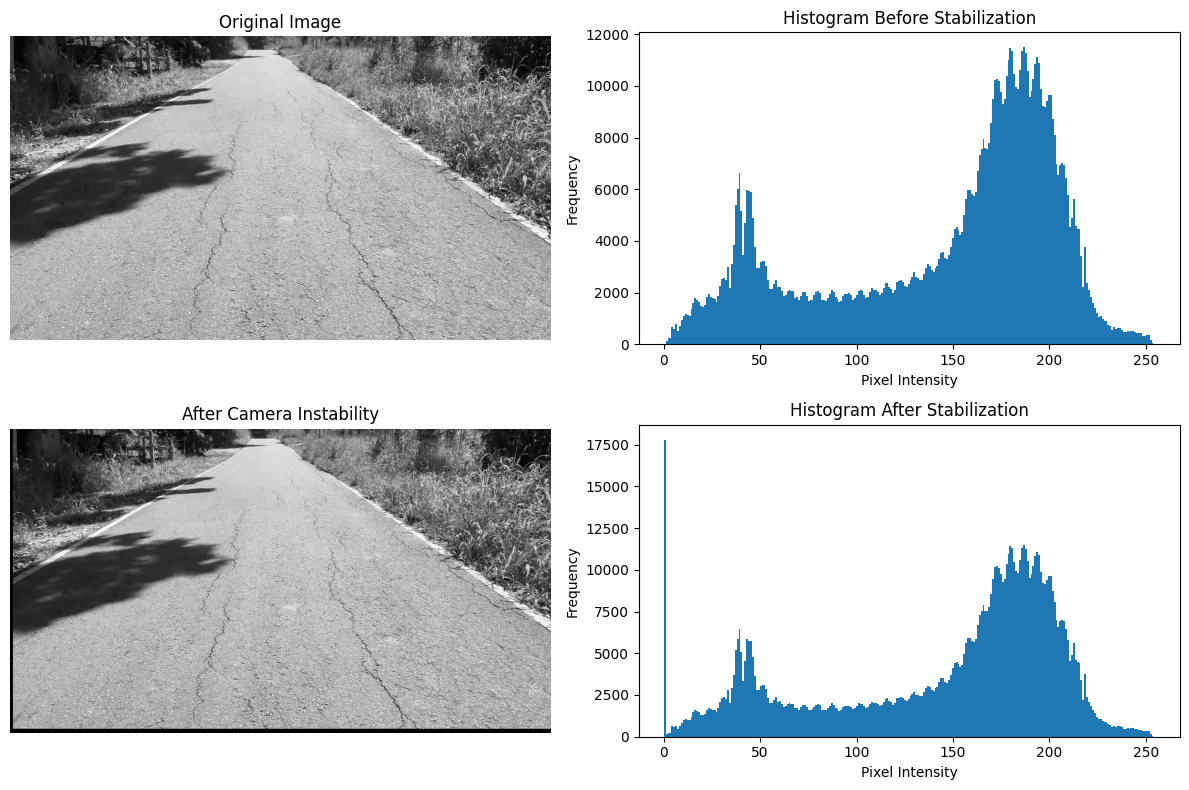

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
img = cv2.imread("frames/frame_100.jpg")

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

rows, cols = gray.shape

# Simulate camera instability (random shift)
dx = np.random.randint(-10, 10)
dy = np.random.randint(-10, 10)

# Translation matrix
M = np.float32([
    [1, 0, dx],
    [0, 1, dy]
])

# Apply camera instability
shifted = cv2.warpAffine(gray, M, (cols, rows))

# Plot images and histograms
plt.figure(figsize=(12,8))

# Original image
plt.subplot(2,2,1)
plt.title("Original Image")
plt.imshow(gray, cmap='gray')
plt.axis('off')

# Histogram before stabilization
plt.subplot(2,2,2)
plt.title("Histogram Before Stabilization")
plt.hist(gray.ravel(), bins=256)
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

# Shifted image
plt.subplot(2,2,3)
plt.title("After Camera Instability")
plt.imshow(shifted, cmap='gray')
plt.axis('off')

# Histogram after stabilization
plt.subplot(2,2,4)
plt.title("Histogram After Stabilization")
plt.hist(shifted.ravel(), bins=256)
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()